In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.svm import SVR

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import joblib

In [19]:
data = pd.read_csv("dataset.csv")

print("Dataset Shape:", data.shape)
data.head()

Dataset Shape: (109, 7)


,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0


In [20]:
print("Dataset Information:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      100 non-null    object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.1+ KB
None

Missing Values:
Rain Fall (mm)    10
Fertilizer        10
Temperatue         9
Nitrogen (N)      10
Phosphorus (P)    10
Potassium (K)     10
Yeild (Q/acre)    10
dtype: int64


In [21]:
feature_columns = [
    "Rain Fall (mm)",
    "Fertilizer",
    "Temperatue",
    "Nitrogen (N)",
    "Phosphorus (P)",
    "Potassium (K)"
]

target_column = "Yeild (Q/acre)"

for column in feature_columns + [target_column]:
    data[column] = pd.to_numeric(data[column], errors="coerce")

# Remove rows where target value is missing
data = data.dropna(subset=[target_column])

print("Shape after cleaning:", data.shape)

data.head()

Shape after cleaning: (99, 7)


,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28.0,80.0,24.0,20.0,12.0
1,480.0,60.0,36.0,70.0,20.0,18.0,8.0
2,1250.0,75.0,29.0,78.0,22.0,19.0,11.0
3,450.0,65.0,35.0,70.0,19.0,18.0,9.0
4,1200.0,80.0,27.0,79.0,22.0,19.0,11.0


In [22]:
data[feature_columns + [target_column]].describe()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,849.797980,67.808081,32.393939,70.737374,21.131313,18.060606,9.131313
std,400.042676,10.028202,5.426350,6.677079,1.951695,1.817254,1.930668
min,400.000000,50.000000,24.000000,59.000000,18.000000,15.000000,6.000000
25%,450.000000,60.000000,28.000000,65.000000,19.500000,16.000000,7.000000
50%,1150.000000,70.000000,29.000000,71.000000,21.000000,19.000000,9.000000
75%,1237.500000,77.000000,38.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,40.000000,80.000000,25.000000,22.000000,12.000000


In [23]:
X = data[feature_columns]
y = data[target_column]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Rain Fall (mm)  Fertilizer  Temperatue  Nitrogen (N)  Phosphorus (P)  \
0          1230.0        80.0        28.0          80.0            24.0   
1           480.0        60.0        36.0          70.0            20.0   
2          1250.0        75.0        29.0          78.0            22.0   
3           450.0        65.0        35.0          70.0            19.0   
4          1200.0        80.0        27.0          79.0            22.0   

   Potassium (K)  
0           20.0  
1           18.0  
2           19.0  
3           18.0  
4           19.0  

Target:
0    12.0
1     8.0
2    11.0
3     9.0
4    11.0
Name: Yeild (Q/acre), dtype: float64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 79
Testing samples: 20


In [25]:
model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        loss="huber",
        random_state=42
    ))
])

model.fit(X_train, y_train)

print("Gradient Boosting model trained successfully.")

Gradient Boosting model trained successfully.


In [26]:
y_pred = model.predict(X_test)

print("Actual Yield:")
print(y_test.values)

print("\nPredicted Yield:")
print(y_pred)

Actual Yield:
[11. 11.  7. 11.  7.  9. 11. 11. 12. 12.  6. 12.  8.  6. 11. 11.  7. 11.
 11.  7.]

Predicted Yield:
[11.55894917 10.7712792   7.14925191 10.37771269  7.9282251  10.30163527
 11.02924889 10.7354814  12.21766177 11.91204535  7.36251278 11.89950252
  8.16955177  5.98807321 11.01549488 11.45071409  7.49536446 10.14810607
 10.59228779  7.93384018]


In [27]:
r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("==============================================")
print("CROP YIELD PREDICTION - EVALUATION")
print("==============================================")

print(f"R² Score  : {r2:.4f}")
print(f"R² Percentage: {r2 * 100:.2f}%")
print(f"MAE       : {mae:.4f} Q/acre")
print(f"RMSE      : {rmse:.4f} Q/acre")

CROP YIELD PREDICTION - EVALUATION
R² Score  : 0.9167
R² Percentage: 91.67%
MAE       : 0.4594 Q/acre
RMSE      : 0.6150 Q/acre


In [28]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    model,
    X,
    y,
    cv=kfold,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error"
    }
)

cv_r2 = cv_results["test_r2"]
cv_mae = -cv_results["test_mae"]
cv_rmse = -cv_results["test_rmse"]

print("==============================================")
print("5-FOLD CROSS-VALIDATION")
print("==============================================")

print("R² Scores:")
for i, score in enumerate(cv_r2, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R²:", round(cv_r2.mean(), 4))
print("R² Percentage:", round(cv_r2.mean() * 100, 2), "%")

print("\nMean MAE:", round(cv_mae.mean(), 4), "Q/acre")
print("Mean RMSE:", round(cv_rmse.mean(), 4), "Q/acre")

5-FOLD CROSS-VALIDATION
R² Scores:
Fold 1: 0.9167
Fold 2: 0.7608
Fold 3: 0.8792
Fold 4: 0.9241
Fold 5: 0.8899

Mean R²: 0.8741
R² Percentage: 87.41 %

Mean MAE: 0.4864 Q/acre
Mean RMSE: 0.6436 Q/acre


In [29]:
comparison = pd.DataFrame({
    "Actual Yield (Q/acre)": y_test.values,
    "Predicted Yield (Q/acre)": y_pred
})

comparison["Difference"] = (
    comparison["Actual Yield (Q/acre)"]
    - comparison["Predicted Yield (Q/acre)"]
)

comparison

,Actual Yield (Q/acre),Predicted Yield (Q/acre),Difference
0,11.0,11.558949,-0.558949
1,11.0,10.771279,0.228721
2,7.0,7.149252,-0.149252
3,11.0,10.377713,0.622287
4,7.0,7.928225,-0.928225
5,9.0,10.301635,-1.301635
6,11.0,11.029249,-0.029249
7,11.0,10.735481,0.264519
8,12.0,12.217662,-0.217662
9,12.0,11.912045,0.087955


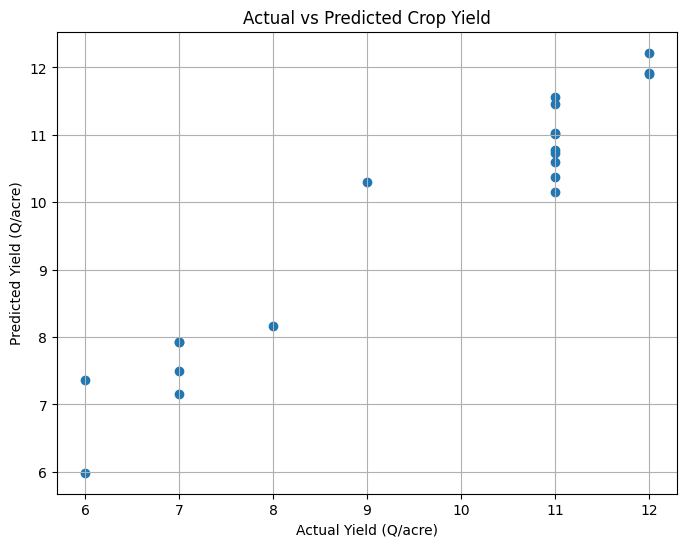

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Yield (Q/acre)")
plt.ylabel("Predicted Yield (Q/acre)")
plt.title("Actual vs Predicted Crop Yield")

plt.grid(True)
plt.show()

In [31]:
regressor = model.named_steps["regressor"]

importance = regressor.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

          Feature  Importance
2      Temperatue    0.488974
0  Rain Fall (mm)    0.281520
5   Potassium (K)    0.152951
3    Nitrogen (N)    0.045470
4  Phosphorus (P)    0.018241
1      Fertilizer    0.012843


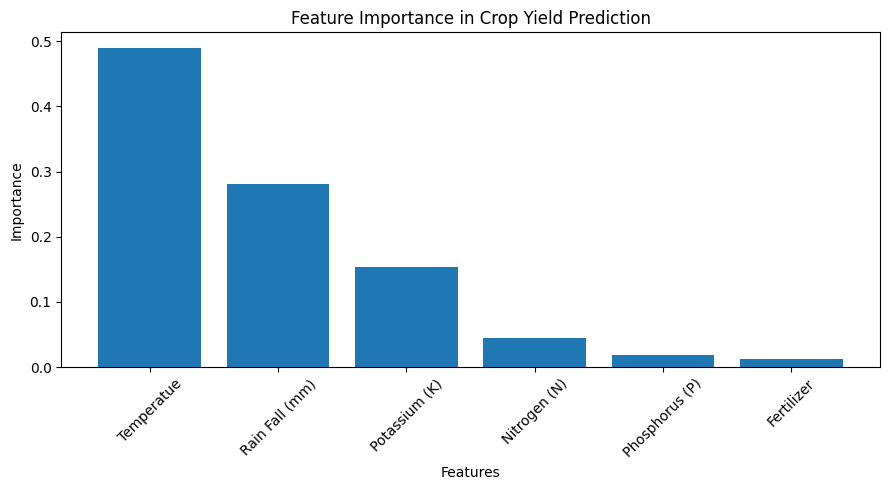

In [32]:
plt.figure(figsize=(9, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance in Crop Yield Prediction")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [33]:
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("regressor", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        loss="huber",
        random_state=42
    ))
])

final_model.fit(X, y)

print("Final Gradient Boosting model trained on complete dataset.")

Final Gradient Boosting model trained on complete dataset.


In [35]:
sample_input = pd.DataFrame({
    "Rain Fall (mm)": [1200],
    "Fertilizer": [150],
    "Temperatue": [25],
    "Nitrogen (N)": [80],
    "Phosphorus (P)": [40],
    "Potassium (K)": [40]
})

predicted_yield = final_model.predict(sample_input)

print("==============================================")
print("CROP YIELD PREDICTION")
print("==============================================")

print(f"Predicted Crop Yield: {predicted_yield[0]:.2f} Q/acre")

CROP YIELD PREDICTION
Predicted Crop Yield: 12.38 Q/acre


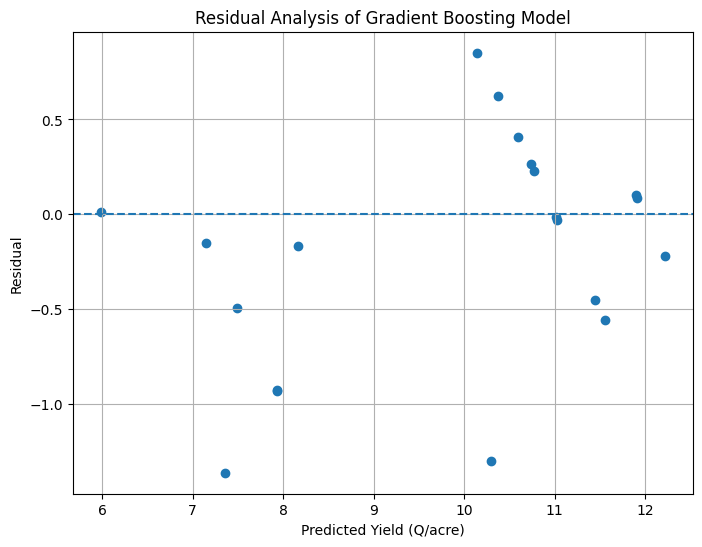

In [36]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield (Q/acre)")
plt.ylabel("Residual")
plt.title("Residual Analysis of Gradient Boosting Model")

plt.grid(True)
plt.show()

In [38]:
results = pd.DataFrame({
    "Model": [
        "Gradient Boosting",
        "Ridge Regression",
        "Linear Regression",
        "Random Forest",
        "Extra Trees",
        "Hist Gradient Boosting",
        "SVR"
    ],
    "R2": [
        87.413895,
        85.493123,
        85.491014,
        84.071386,
        83.292326,
        81.638240,
        76.652367
    ]
})

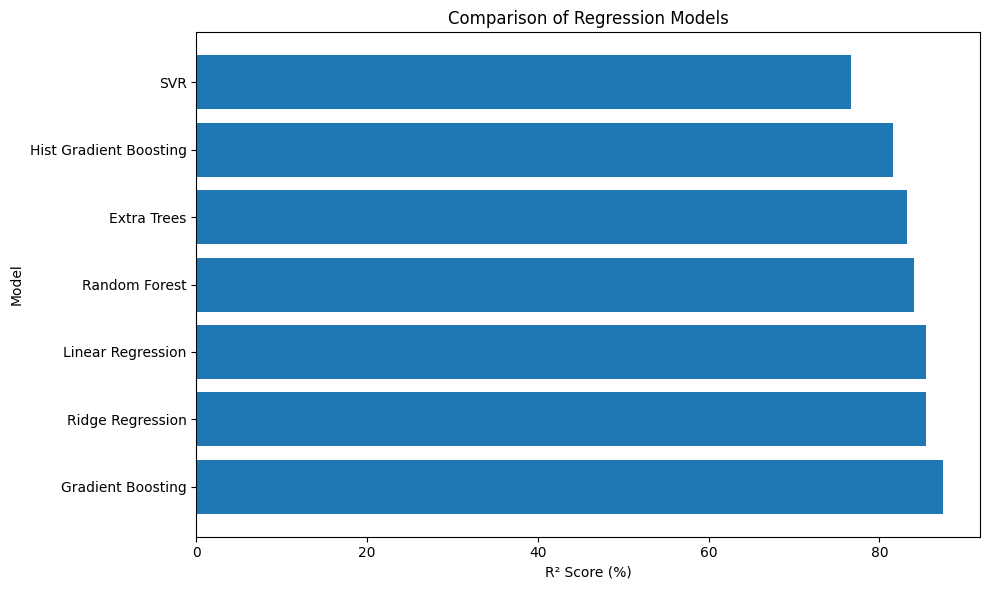

In [39]:
plt.figure(figsize=(10, 6))

plt.barh(
    results["Model"],
    results["R2"]
)

plt.xlabel("R² Score (%)")
plt.ylabel("Model")
plt.title("Comparison of Regression Models")

plt.tight_layout()
plt.show()

In [40]:
joblib.dump(final_model, "crop_yield_model.pkl")

print("Model saved successfully as crop_yield_model.pkl")

Model saved successfully as crop_yield_model.pkl
